In [1]:
import sys
import os
sys.path.append("../")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import json
# import sportsradar data reader
from src.etl_pipeline.models.DataClassGameEvents import DataClassGameEvents

In [2]:
# specify downloaded sportdata json file
path_test_data = "../data/raw/gameday_01/sportradar/2023-08-24_gd_01_id_42307421_teams_HCErlangen_vs_TSVHannover-Burgdorf_sportradar.json"

with open(path_test_data, "r") as f:
    data = json.load(f)


In [3]:
# create data object
data_sportradar = DataClassSportRadar(data)

NameError: name 'DataClassSportRadar' is not defined

In [ ]:
# print game data
print("Game ID:")
print(data_sportradar.id)
print("Start time:")
print(data_sportradar.start_time)
print("sport_event_context:")
print(data_sportradar.sport_event_context)
print("sport_event_conditions:")
print(data_sportradar.sport_event_conditions)
print("sport_event_status:")
print(data_sportradar.sport_event_status)
print("competitors:")
print(data_sportradar.competitors)
# print player details of competitors
for competitor in data_sportradar.competitors:
    print("Players of competitor:")
    print(competitor.name)
    print(competitor.players)
    print(competitor.statistics)
    for player in competitor.players:
        print("Player:")
        print(player)
        print(player.statistics)

print(data_sportradar.venue)

Game ID:
sr:sport_event:42307421
Start time:
2023-08-24 17:00:00+00:00
sport_event_context:
SportEventContext(sport=Handball, category=Germany, competition=Bundesliga, season=Bundesliga 23/24, stage=league, round=1)
sport_event_conditions:
SportEventConditions(referees=[Referee ID: sr:referee:1944116, Name: Kuttler, Tanja, Nationality: Germany, Type: referee, Referee ID: sr:referee:998417, Name: Merz, Maike, Nationality: Germany, Type: referee], attendance=5136, ground_neutral=False)
sport_event_status:
Status: closed, Match Status: ended, Home Score: 25, Away Score: 27, Winner ID: sr:competitor:5447
competitors:
[CompetitorStats(id=sr:competitor:6288, name=HC Erlangen, abbreviation=HCE, qualifier=home, statistics={'assists': 9, 'blocks': 2, 'field_goals': 22, 'goals_conceded': 27, 'goals_scored': 25, 'red_cards': 1, 'saves': 14, 'seven_m_goals': 3, 'shot_accuracy': 56.82, 'shots': 44, 'shots_against': 44, 'shots_off_goal': 3, 'shots_on_goal': 39, 'steals': 2, 'suspensions': 5, 'techni

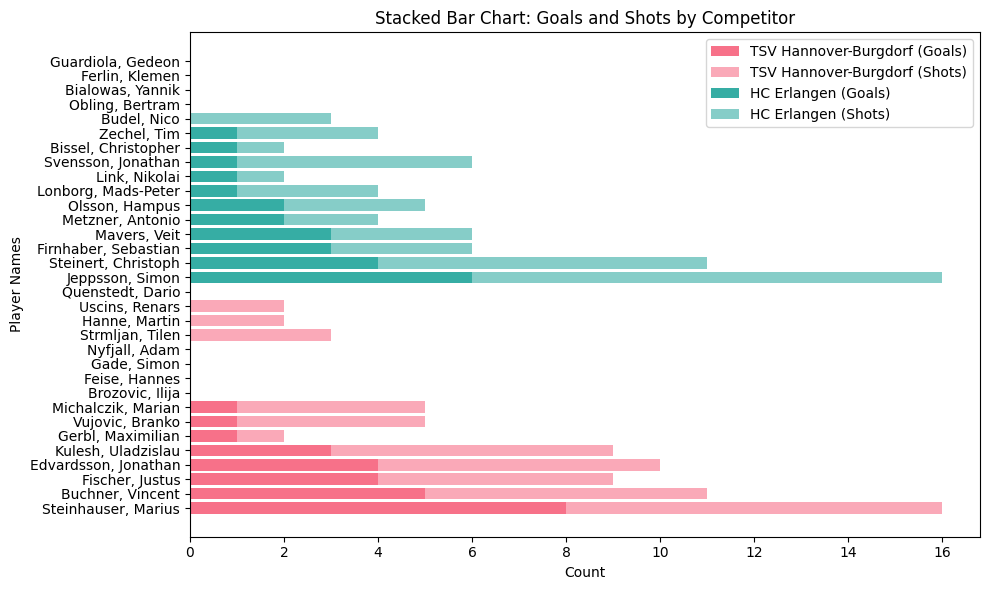

In [ ]:
# histogram of players and goals
df_players = pd.DataFrame()

for competitor in data_sportradar.competitors:
    for player in competitor.players:
        name_player = player.name
        competitor_name = competitor.name
        player.competitor = competitor_name
        player.goals = player.statistics["goals_scored"]
        player.shots = player.statistics["shots"]
        
        df_players = pd.concat([df_players, pd.DataFrame([player.__dict__])], ignore_index=True)


# sort by goals
df_players = df_players.sort_values(by="goals", ascending=False)

# Erstelle die gestapelten Balkendiagramme
fig, ax = plt.subplots(figsize=(10, 6))

# Iteriere über jeden Wettbewerber
competitors = df_players['competitor'].unique()
colors = sns.color_palette('husl', len(competitors))

for i, competitor in enumerate(competitors):
    # Filter nach Wettbewerber
    subset = df_players[df_players['competitor'] == competitor]

    # Plotte Goals
    ax.barh(
        subset['name'], 
        subset['goals'], 
        color=colors[i], 
        label=f'{competitor} (Goals)'
    )

    # Plotte Shots oben auf Goals
    ax.barh(
        subset['name'], 
        subset['shots'], 
        left=subset['goals'],  # Stapeln über Goals
        color=colors[i], 
        alpha=0.6,
        label=f'{competitor} (Shots)'
    )

# Labels und Legende
ax.set_xlabel('Count')
ax.set_ylabel('Player Names')
ax.set_title('Stacked Bar Chart: Goals and Shots by Competitor')
ax.legend()
plt.tight_layout()
plt.show()